# 01 — Preprocessing
Load the raw Online Retail dataset, perform some preprocessing, and save the processed dataset.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# Add project root to path so `src` is importable
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_raw, clean

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Load raw data
raw = load_raw()
print(f"Loaded {len(raw):,} rows")

Loaded 541,909 rows


In [3]:
# Testing for invalid data cases
print("Shape:", raw.shape)
print("\nDtypes:")
print(raw.dtypes)
print("\nMissing value counts:")
print(raw.isnull().sum())
print("\nSample rows:")
raw.head()

Shape: (541909, 8)

Dtypes:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID             object
Country                object
dtype: object

Missing value counts:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Sample rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [4]:
# Apply cleaning
df = clean(raw)
print(f"Before cleaning : {len(raw):,} rows")
print(f"After cleaning  : {len(df):,} rows")
print(f"Rows removed    : {len(raw) - len(df):,} ({(len(raw) - len(df)) / len(raw) * 100:.1f}%)")

Before cleaning : 541,909 rows
After cleaning  : 530,104 rows
Rows removed    : 11,805 (2.2%)


In [5]:
# Show some statistics about the data
print("Date range:")
print(f"  {df['InvoiceDate'].min()}  →  {df['InvoiceDate'].max()}")
print(f"\nUnique customers : {df['CustomerID'].nunique():,}")
print(f"Unique products  : {df['StockCode'].nunique():,}")
print(f"Unique invoices  : {df['InvoiceNo'].nunique():,}")
print("\nTop 10 countries by transaction count:")
print(df['Country'].value_counts().head(10))

Date range:
  2010-12-01 08:26:00  →  2011-12-09 12:50:00

Unique customers : 4,338
Unique products  : 3,922
Unique invoices  : 19,960

Top 10 countries by transaction count:
Country
United Kingdom    485123
Germany             9040
France              8407
EIRE                7890
Spain               2484
Netherlands         2359
Belgium             2031
Switzerland         1966
Portugal            1501
Australia           1182
Name: count, dtype: int64


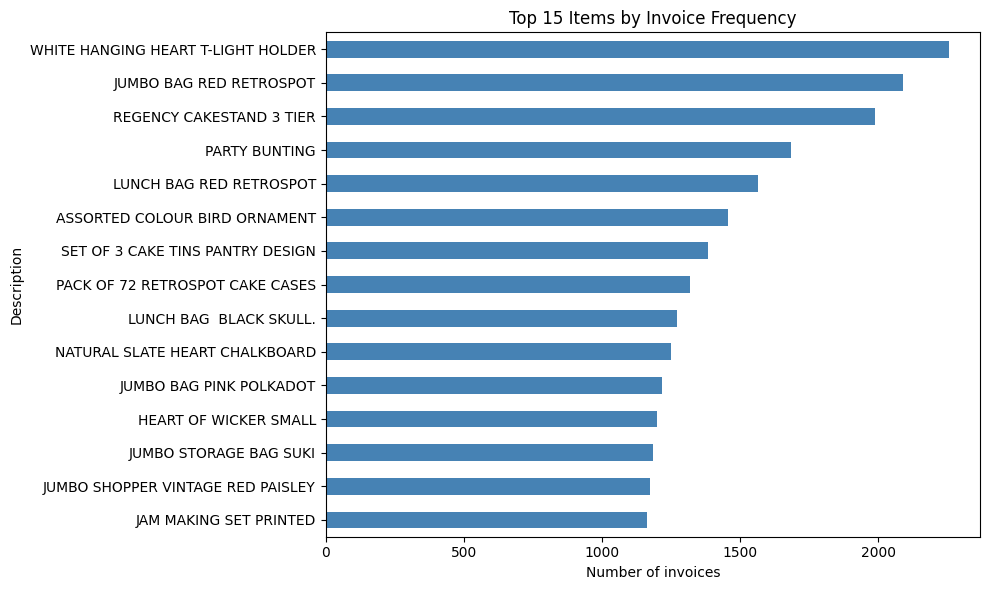

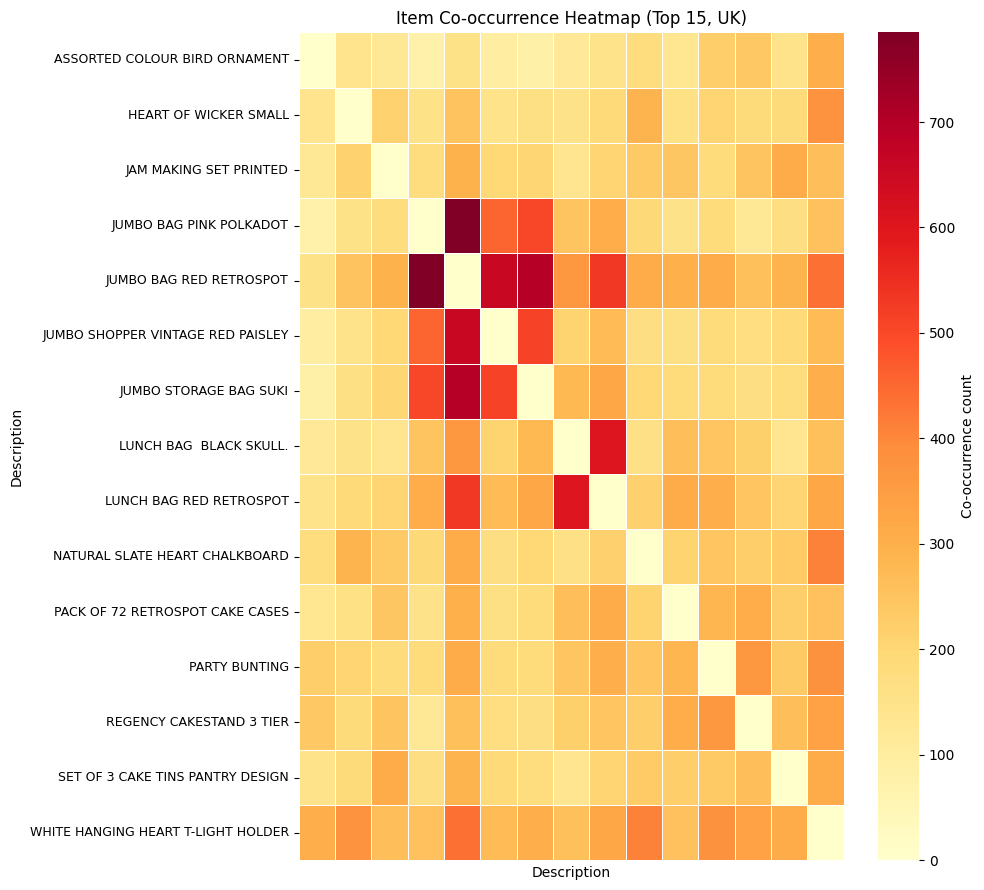

In [6]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

# Top 15 most frequently purchased items
top_items = (
    df.groupby("Description")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

# Bar chart of item frequency
fig, ax = plt.subplots(figsize=(10, 6))
top_items.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Number of invoices")
ax.set_title("Top 15 Items by Invoice Frequency")
plt.tight_layout()
plt.show()

# Co-occurrence heatmap for top 15 items
top_names = top_items.index.tolist()

uk_df = df[df["Country"] == "United Kingdom"]
basket = (
    uk_df[uk_df["Description"].isin(top_names)]
    .groupby(["InvoiceNo", "Description"])["Quantity"]
    .sum()
    .unstack(fill_value=0)
    .map(lambda x: 1 if x > 0 else 0)
)

cooc = basket.T.dot(basket)
for item in cooc.columns:
    cooc.loc[item, item] = 0

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(
    cooc,
    ax=ax,
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Co-occurrence count"},
    xticklabels=False,  # very hard to fit long labels on the bottom of the matrix
)
ax.set_title("Item Co-occurrence Heatmap (Top 15, UK)")
ax.tick_params(axis="y", rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# Save processed data as a CSV file
out_path = PROCESSED_DIR / "online_retail_clean.csv"
df.to_csv(out_path, index=False)
print(f"Saved {len(df):,} rows → {out_path}")